In [2]:
import pandas as pd

bbox_df = pd.read_csv('data/list_bbox_celeba.txt', sep='\s+', skiprows=1, index_col=0)
attr_df = pd.read_csv('data/list_attr_celeba.txt', sep='\s+', skiprows=1, index_col=0)
landmarks_df = pd.read_csv('data/list_landmarks_celeba.txt', sep='\s+', skiprows=1, index_col=0)

combined_df = bbox_df.join([attr_df, landmarks_df])

combined_df.reset_index(inplace=True)
combined_df.rename(columns={'index': 'image_id'}, inplace=True)

combined_df.replace(-1, 0, inplace=True)

combined_df.head()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mereh\AppData\Local\Temp\ipykernel_16784\1991134295.py:3: SyntaxWarning: invalid escape sequence '\s'
  bbox_df = pd.read_csv('data/list_bbox_celeba.txt', sep='\s+', skiprows=1, index_col=0)
C:\Users\mereh\AppData\Local\Temp\ipykernel_16784\1991134295.py:4: SyntaxWarning: invalid escape sequence '\s'
  attr_df = pd.read_csv('data/list_attr_celeba.txt', sep='\s+', skiprows=1, index_col=0)
C:\Users\mereh\AppData\Local\Temp\ipykernel_16784\1991134295.py:5: SyntaxWarning: invalid escape sequence '\s'
  landmarks_df = pd.read_csv('data/list_landmarks_celeba.txt', sep='\s+', skiprows=1, index_col=0)


,image_id,x_1,y_1,width,height,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,...,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,95,71,226,313,0,1,1,0,0,...,165,184,244,176,196,249,194,271,266,260
1,000002.jpg,72,94,221,306,0,0,0,1,0,...,140,204,220,204,168,254,146,289,226,289
2,000003.jpg,216,59,91,126,0,0,0,0,0,...,244,104,264,105,263,121,235,134,251,140
3,000004.jpg,622,257,564,781,0,0,1,0,0,...,796,539,984,539,930,687,762,756,915,756
4,000005.jpg,236,109,120,166,0,1,1,0,0,...,273,169,328,161,298,172,283,208,323,207


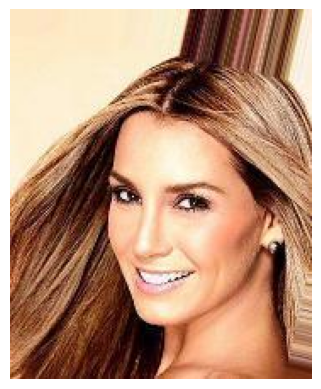

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

image_folder = "data/img_align_celeba"

img_name = combined_df.iloc[0]['image_id']

img_path = os.path.join(image_folder, img_name)

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()

Face detected at: x=40, y=74, width=100, height=100


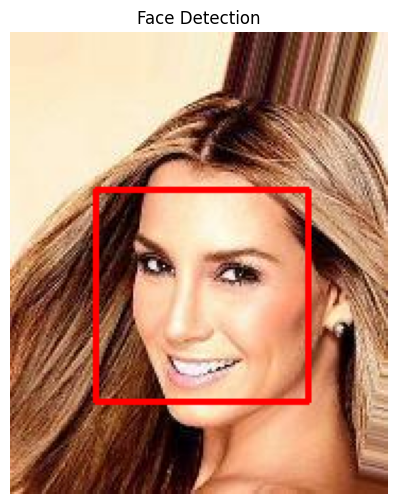

In [6]:
import cv2
import matplotlib.pyplot as plt

image_path = "data/img_align_celeba/000001.jpg"

img = cv2.imread(image_path)

if img is None:
    print("Image not found!")
else:

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        'haarcascade_frontalface_default.xml'
    )


    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )



    for (x, y, w, h) in faces:

        cv2.rectangle(
            img_rgb,
            (x, y),
            (x + w, y + h),
            (255, 0, 0),
            2
        )

        print(f"Face detected at: x={x}, y={y}, width={w}, height={h}")


    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Face Detection")
    plt.show()

In [ ]:
import cv2
import pandas as pd
import os


image_folder = "img_align_celeba"



face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)



data = []



for image_name in os.listdir(image_folder):

    image_path = os.path.join(image_folder, image_name)

    img = cv2.imread(image_path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Face Detection
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (x, y, w, h) in faces:

        data.append({
            'image_id': image_name,
            'x': x,
            'y': y,
            'width': w,
            'height': h
        })


faces_df = pd.DataFrame(data)



faces_df.to_csv("detected_faces.csv", index=False)

print("Face Detection Finished!")
print(faces_df.head())

In [ ]:
import cv2
import pandas as pd
import os

# =========================================
# 1) مسار فولدر الصور
# =========================================

image_folder = "data/img_align_celeba"

# =========================================
# 2) تحميل Face Detection Model
# =========================================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)

# =========================================
# 3) قائمة لتخزين النتائج
# =========================================

detected_faces = []

# =========================================
# 4) قراءة كل الصور من الفولدر
# =========================================

for image_name in os.listdir(image_folder):

    # المسار الكامل للصورة
    image_path = os.path.join(image_folder, image_name)

    # قراءة الصورة
    img = cv2.imread(image_path)

    # لو الصورة لم تُقرأ
    if img is None:
        continue

    # =========================================
    # 5) تحويل الصورة إلى Grayscale
    # =========================================

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # =========================================
    # 6) تنفيذ Face Detection
    # =========================================

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    # =========================================
    # 7) حفظ أول وجه تم اكتشافه
    # =========================================

    if len(faces) > 0:

        x, y, w, h = faces[0]

        detected_faces.append({
            'image_id': image_name,
            'x': x,
            'y': y,
            'width': w,
            'height': h
        })

# =========================================
# 8) تحويل النتائج إلى DataFrame
# =========================================

faces_df = pd.DataFrame(detected_faces)

# =========================================
# 9) حفظ النتائج في CSV
# =========================================

faces_df.to_csv("detected_faces.csv", index=False)

# =========================================
# 10) طباعة النتائج
# =========================================

print("Face Detection Finished Successfully!")
print(f"Number of detected faces: {len(faces_df)}")

print("\nFirst 5 rows:")
print(faces_df.head())